In [2]:
Line_brightness = 10000; NLines = 100
theta_tolerance = 0.1; rhos_tolerance = 60

#################### SUB ARRAYS
import psutil
import pandas as pd
def Save_Files(file,wtype,text):
    with open(file, wtype) as f:
        f.write(text)
        
def Flag(Image):
    if np.sum(Image.ravel() > 90*10**3) > 3000:
        return False #Image is saturated
    
    return True

def SeeAtitudeValue(AttitudeData, ImageTime):
    AttitudeTimeArray = AttitudeData['MJD_TIME']
    Roll_Angles = AttitudeData['SC_ROLL_ANGLE']
    index = np.argmin(np.abs(np.array([a-time for a in AttitudeTimeArray])))
    return Roll_Angles[index], (Roll_Angles[index+1] - Roll_Angles[index]) / (AttitudeTimeArray[index+1] - AttitudeTimeArray[index])



with open('Ignorar.txt','r') as t:
    SkipFiles = []
    while True:
        linha = t.readline()
        if linha == '':
            break
        SkipFiles.append(linha.strip())
    SkipFiles = np.array(SkipFiles)


np.set_printoptions(linewidth=np.inf)


Folder = 'data/user/che_data_dev/repo'
files = np.array(sorted(os.listdir(Folder)))
PSF_file = fits.open('PSF2020_2.fits')
PSF = PSF_file[1].data[0]
PSF_file.close()

Save_Files('Completeness96_1.csv','w','FileName,Frame,TrueTheta,TrueRho,NLines,Theta,Rho,Match\n')
Save_Files('SkippedCompleteness.csv','w','FileName\n')
df = pd.read_csv('Completeness96_3.csv')

for Progress in range(int(len(df)/NLines)):
    Frame = df['Frame'][NLines*Progress]; file1 = df['FileName'][NLines*Progress]
    dataFolder = file1[5:11] + file1[14:20] 
  
    FileFolder = f"{Folder}/{dataFolder}/L1/SCI_COR_SubArray"
    file = f'{FileFolder}/{file1}'
    myFits = fits.open(file)
    header = myFits[1].header
    Images = myFits[1].data
    print(dataFolder, Progress, len(df)/100, 'SizeFile: ', os.path.getsize(file)/1073741824, 'RAM: ',psutil.Process(os.getpid()).memory_info().rss / 1073741824, 'NFilesOpen: ', len(psutil.Process().open_files()), end='\r') 
    scale_val, medians = ChooseScale(Images)
    
    
    Image_previous = Images[Frame-1]; Image = Images[Frame]
    Image_previous -= np.nanmedian(Image_previous); Image -= np.nanmedian(Image)
    scale = max(1,scale_val)
    EdgeMap = EdgeDetection(Image_previous, mode = 'Canny', CannyLowThreshold = scale*600, CannyHighThreshold = scale*1000)
    for i in range(NLines):
        Image_line = Image.copy()
        TrueRho, TrueTheta = df['TrueRho'][NLines*Progress + i], df['TrueTheta'][NLines*Progress + i]
        Image_line = AddSpecificLine(Image_line,Line_brightness,PSF,TrueRho,TrueTheta)
        edges, a = EdgeDetection(Image_line, mode = 'Canny', CannyLowThreshold = scale*600, CannyHighThreshold = scale*1000, EdgeMap = EdgeMap, dilation_iterations = 3)
        lines = LineDetection(edges, theta_tolerance = theta_tolerance, rhos_tolerance = rhos_tolerance, mode = 'Hough')
        
        Match = False
        if lines is not None:
            rho, theta = lines[0,0,:][0], lines[0,0,:][1] 
            theta_dif = np.abs(np.arctan(np.sin(theta - TrueTheta)/ np.cos(theta - TrueTheta)))
            rho_dif1 = np.abs(rho - TrueRho); rho_dif2 = np.abs(rho + TrueRho)

            if theta_dif <= theta_tolerance and (rho_dif1 < rhos_tolerance or (rho_dif2 < rhos_tolerance and abs(theta-TrueTheta)>np.pi-2*theta_tolerance)):
                Match = True

            
            Save_Files('Completeness96_1.csv','a',f'{file1},{Frame},{TrueTheta},{TrueRho},{len(lines)},{lines[:,0,1][0]},{lines[:,0,0][0]},{Match}\n')
        else:
            Save_Files('Completeness96_1.csv','a',f'{file1},{Frame},{TrueTheta},{TrueRho},{0},{np.nan},{np.nan},{Match}\n')
    del Image

    myFits.close()
    




/tmp/ipykernel_7111/3771100617.py:33: RuntimeWarning: divide by zero encountered in scalar divide
  y0 = rho  /  np.sin(theta)
/tmp/ipykernel_7111/3771100617.py:38: RuntimeWarning: divide by zero encountered in scalar divide
  y0 = (rho - width * np.cos(theta)) / np.sin(theta)


In [4]:
import pandas as pd
df_1 = pd.read_csv('Completeness96_1.csv')
df_2 = pd.read_csv('Completeness96_2.csv')
df_3 = pd.read_csv('Completeness96_3.csv')
df_4 = pd.read_csv('Completeness96_4.csv')
print(df_2.columns)
Total = len(df_2)
Correct1 = np.sum(df_1['Match']==True); FP_1 = (df_1['Match'] == False) & (~np.isnan(df_1['Rho']))
Correct2 = np.sum(df_2['Match']==True); FP_2 = (df_2['Match'] == False) & (~np.isnan(df_2['Rho']))
Correct3 = np.sum(df_3['Match']==True); FP_3 = (df_3['Match'] == False) & (~np.isnan(df_3['Rho']))
Correct4 = np.sum(df_4['Match']==True); FP_4 = (df_4['Match'] == False) & (~np.isnan(df_4['Rho']))

CorrectS1 = np.sum( (df_1['Match']==True) | (df_2['Match']==True)   )
CorrectS2 = np.sum( (df_3['Match']==True) | (df_4['Match']==True)   )

CorrectS = np.sum( (df_1['Match']==True) | (df_2['Match']==True) | (df_3['Match']==True) | (df_4['Match']==True)   )
print('Total tests: ', Total)
print('Correct Images 1: ', Correct1, 'False Positives :', np.sum(FP_1))
print('Correct Images 2: ', Correct2, 'False Positives :', np.sum(FP_2))
print('Correct Images 3: ', Correct3, 'False Positives :', np.sum(FP_3))
print('Correct Images 4: ', Correct4, 'False Positives :', np.sum(FP_4))
print('Correct Images S: ', CorrectS, np.sum(FP_1 & FP_2 & FP_3 & FP_4) )

print('Correct Images S1: ', CorrectS1, np.sum(FP_1 & FP_2) )
print('Correct Images S2: ', CorrectS2, np.sum(FP_3 & FP_4) )

print('Percentage: ', CorrectS/Total * 100, '%')

Index(['FileName', 'Frame', 'TrueTheta', 'TrueRho', 'NLines', 'Theta', 'Rho',
       'Match'],
      dtype='object')
Total tests:  359200
Correct Images 1:  260056 False Positives : 1477
Correct Images 2:  260089 False Positives : 1484
Correct Images 3:  285122 False Positives : 2094
Correct Images 4:  309138 False Positives : 1512
Correct Images S:  324734 628
Correct Images S1:  260147 1474
Correct Images S2:  321086 709
Percentage:  90.40478841870824 %


50062
RHO, THETA:  77.08715431360247 0.6522618358458007
Match:  False
SCALE:  1 PARAMETRO:  2.2886808362754176 NEXP:  14
Detected:  80.0 0.6632251


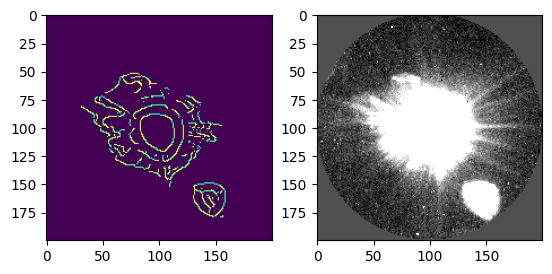

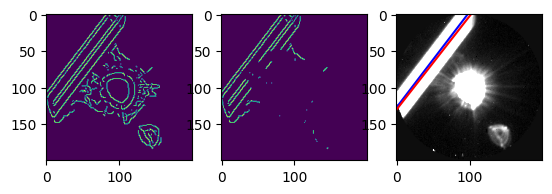

In [37]:
ErroImages = df_4[df_4['Match'] !=True].index
power = 1
#35006
Example = ErroImages[12005]
print(len(ErroImages))
image_name = df_4['FileName'][Example]; Frame = df_4['Frame'][Example]; rho = df_4['TrueRho'][Example]; theta = df_4['TrueTheta'][Example]; Match = df_4['Match'][Example]
Number = image_name[5:11] + image_name[14:20] 
print('RHO, THETA: ',rho,theta)
print('Match: ', Match)
Folder = 'data/user/che_data_dev/repo'
FileFolder = f"{Folder}/{Number}/L1/SCI_COR_SubArray"
file1 = sorted(os.listdir(FileFolder))[-1]
file = f'{FileFolder}/{file1}'
myFits = fits.open(file)
header = myFits[1].header
Images = myFits[1].data / header['NEXP']


skip = False
Image_previous = Images[Frame-1]; Image = Images[Frame]
Image_previous -= np.nanmedian(Image_previous); Image -= np.nanmedian(Image)
parametro = DetermineSpread(Image); parametro_previous = DetermineSpread(Image)
scale_val, medians = ChooseScale(Images)
#scale = max(1,scale_val)
#scale = max(1,scale_val * np.exp(-3.14427*10**-3 * (20/parametro) ))
scale = max(1, 58.5442 * np.exp(-3.14427*10**-3 * medians * (20/parametro)**power ))
print('SCALE: ', scale, 'PARAMETRO: ', parametro, 'NEXP: ', header['NEXP'])
        
EdgeMap = EdgeDetection(Image_previous, mode = 'Canny', CannyLowThreshold = scale*600, CannyHighThreshold = scale*1000)
Image_line = Image.copy()

Image_line = AddSpecificLine(Image_line,Line_brightness,PSF,rho,theta)
edges, a = EdgeDetection(Image_line, mode = 'Canny', CannyLowThreshold = scale*600, CannyHighThreshold = scale*1000, EdgeMap = EdgeMap, dilation_iterations = 3)
lines = LineDetection(edges, theta_tolerance = theta_tolerance, rhos_tolerance = rhos_tolerance, mode = 'Hough')
fig, axis = plt.subplots(1,2); axis[0].imshow(EdgeMap); axis[1].imshow(Image_previous,cmap='gray',vmin=None or np.nanpercentile(Image_previous,1),vmax=None or np.nanpercentile(Image_previous, 85))
fig, axis = plt.subplots(1,3); axis[0].imshow(a); axis[1].imshow(edges); axis[2].imshow(Image_line,cmap='gray',vmin=None or np.nanpercentile(Image_line,1),vmax=None or np.nanpercentile(Image_line, 85))
x0 = np.cos(theta) * rho
y0 = np.sin(theta) * rho
axis[2].axline((x0, y0), slope=np.tan(theta + np.pi / 2), color = 'b')


if lines is not None:
    RHOS = lines[:,0,0] ; THETAS = lines[:,0,1]
    for rho, theta in zip(RHOS,THETAS):
        print('Detected: ', rho,theta)
        x0 = np.cos(theta) * rho
        y0 = np.sin(theta) * rho
        axis[2].axline((x0, y0), slope=np.tan(theta + np.pi / 2), color = 'r')


        

In [1]:
import sys
import os
import matplotlib.pyplot as plt
path = '/home/lgoncalv/.local/lib/python3.11/site-packages'
sys.path.append(path)


import numpy as np
from scipy import ndimage
import cv2
from skimage.feature import peak_local_max
from scipy.signal import convolve2d, fftconvolve
from scipy.fft import fft2, ifft2
from skimage.restoration import richardson_lucy
from skimage.transform import radon, rescale
import random
import matplotlib.pyplot as plt
from astropy.io import fits





# Help Functions

def calculate_border_points(rho,theta,shape):
    height, width = shape
    height -= 1; width -= 1
    intersections = []
    eps = 10**-5

    x0 = 0
    y0 = rho  /  np.sin(theta)
    if y0 >= 0 and y0 <= height:
        intersections.append([x0,int(y0)])
    
    x0 = width
    y0 = (rho - width * np.cos(theta)) / np.sin(theta)
    if y0 > -eps and y0 < height + eps:
        intersections.append([x0-1,int(y0)])

    y0 = 0
    x0 = rho  /  np.cos(theta)
    if x0 > 0 and x0 < width:
        intersections.append([int(x0),y0])
        

    y0 = height
    x0 = (rho - height * np.sin(theta)) / np.cos(theta)
    if x0 > -eps and x0 < width:
        intersections.append([int(x0),y0-1])
    return intersections[0][0], intersections[0][1], intersections[1][0], intersections[1][1]

def calculate_mid_point(rho,theta,shape):
    x0,y0 , x1,y1 = calculate_border_points(rho,theta,shape)
    return (x0+x1)/2, (y0+y1)/2

def convert_to_rho_theta(x1, y1, x2, y2):
    # Calculate the angle theta
    theta = np.arctan2((y2 - y1), (x2 - x1))  + np.pi/2# Angle of the line in radians
    
    # Calculate rho using one point on the line (x1, y1)
    rho = x1 * np.cos(theta) + y1 * np.sin(theta)
    

    return rho, theta

def DetermineSpread(ImageData):
    mask1 = ImageData < 500
    mask2 = ImageData > -500
    mask3 = ImageData != 0
    mask = (mask1) & (mask2) & (mask3)
    Image = ImageData[mask]

    hist, bin_edges = np.histogram(Image,bins=100)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    peak_idx = np.argmax(hist)
    peak_value = bin_centers[peak_idx]
    left_side_data = Image[Image<peak_value] 
    std = np.sqrt(np.sum( (left_side_data - peak_value) **2) / (len(left_side_data) -1) )
    return std

def ChooseScale(cube):
    percentiles = [np.nanpercentile(cube[i], 96) for i in range(cube.shape[0])]
    medians = np.median(percentiles)
    return 58.5442*np.exp(-3.14427*medians*10**-3), medians

#Add noise and Deconvolution 

def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    # Create a copy of the image
    noisy_image = np.copy(image)
    
    # Generate salt noise
    num_salt = np.ceil(salt_prob * image.size).astype(int)
    coords = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy_image[tuple(coords)] = 5
    
    # Generate pepper noise
    num_pepper = np.ceil(pepper_prob * image.size).astype(int)
    coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    
    return noisy_image

def preprocess_image(image):
    """ Replace NaNs with zeros or another suitable value before processing. """
    return np.nan_to_num(image, nan=0.0)

def FFT_deconvolve(image, kernel):
    """ Perform deconvolution in the Fourier domain. """
    # Preprocess the image and kernel
    image = preprocess_image(image)
    kernel = preprocess_image(kernel)
    
    # Pad the kernel to the same size as the image
    kernel_padded = np.zeros_like(image)

    kernel_padded[:kernel.shape[0], :kernel.shape[1]] = kernel

    # offset_x = (image.shape[0] - kernel.shape[0]) // 2
    # offset_y = (image.shape[1] - kernel.shape[1]) // 2
    # kernel_padded = np.zeros_like(image)
    # kernel_padded[offset_y:offset_y+kernel.shape[0], offset_x:offset_x+kernel.shape[1]] = kernel
    
    # Fourier transform of the image and kernel
    image_fft = fft2(image)
    kernel_fft = fft2(kernel_padded)
    
    # Deconvolution: divide in Fourier domain
    with np.errstate(divide='ignore', invalid='ignore'):
        deconvolved_fft = np.divide(image_fft, kernel_fft, where=(kernel_fft != 0))
    
    # Inverse Fourier transform to get the deconvolved image
    deconvolved = ifft2(deconvolved_fft)
    
    # Take the real part of the result and return
    return np.real(deconvolved)

def wiener_deconvolve(image, kernel, K=0.01):
    """Perform Wiener deconvolution."""
    # Preprocess the image and kernel
    image = preprocess_image(image)
    kernel = preprocess_image(kernel)
    
    # # Pad the kernel to the same size as the image
    offset_x = (image.shape[0] - kernel.shape[0]) // 2
    offset_y = (image.shape[1] - kernel.shape[1]) // 2
    kernel_padded = np.zeros_like(image)
    kernel_padded[offset_y:offset_y+kernel.shape[0], offset_x:offset_x+kernel.shape[1]] = kernel


    # Fourier transform of the image and kernel
    image_fft = fft2(image)
    kernel_fft = fft2(kernel_padded)
    # kernel_fft = fft2(kernel)
    
    # Wiener deconvolution formula
    deconvolved_fft = image_fft * (np.conj(kernel_fft) / (np.abs(kernel_fft)**2 + K))

    # deconvolved_fft = image_fft / (kernel_fft * (1 + K/np.abs(kernel_fft)**2))
    
    # Inverse Fourier transform to get the deconvolved image
    deconvolved = ifft2(deconvolved_fft)
    
    # Take the real part of the result and return
    return np.real(deconvolved)

def richardson_lucy_deconvolve(image, kernel, iterations=10000):
    """Perform Richardson-Lucy deconvolution."""
    # Preprocess the image and kernel
    image = preprocess_image(image)
    kernel = preprocess_image(kernel)
    
    # Richardson-Lucy deconvolution
    deconvolved = richardson_lucy(image, kernel, num_iter=iterations)
    
    return deconvolved

def tikhonov_deconvolve(image, kernel, lambda_reg=0.01):
    """Perform Tikhonov regularization deconvolution."""
    # Preprocess the image and kernel
    image = preprocess_image(image)
    kernel = preprocess_image(kernel)
    
    # Pad the kernel to the same size as the image
    kernel_padded = np.zeros_like(image)
    kernel_padded[:kernel.shape[0], :kernel.shape[1]] = kernel
    
    plt.imshow(kernel_padded); plt.show()
    # Fourier transform of the image and kernel
    image_fft = fft2(image)
    kernel_fft = fft2(kernel_padded)
    
    # Tikhonov deconvolution formula
    deconvolved_fft = image_fft * (np.conj(kernel_fft) / (np.abs(kernel_fft)**2 + lambda_reg)) 
    
    # Inverse Fourier transform to get the deconvolved image
    deconvolved = ifft2(deconvolved_fft)
    
    # Take the real part of the result and return
    return np.real(deconvolved)

def landweber_deconvolve(image, kernel, num_iterations=50, relaxation_factor=0.002):
    """Perform Landweber deconvolution."""
    # Preprocess the image and kernel
    image = preprocess_image(image)
    kernel = preprocess_image(kernel)
    
    # Initialize the deconvolved image with zeros
    deconvolved = np.zeros_like(image)
    
    # Pad the kernel to the same size as the image
    kernel_padded = np.zeros_like(image)
    kernel_padded[:kernel.shape[0], :kernel.shape[1]] = kernel
    
    # Perform iterations
    for _ in range(num_iterations):
        residual = convolve2d(deconvolved, kernel, mode='same') - image
        deconvolved -= relaxation_factor * convolve2d(residual, kernel[::-1, ::-1], mode='same')
    
    return deconvolved


# Line Detection

def ProcessLinesMedian(lines, theta_tolerance=0.1, rhos_tolerance = 60, method='median'):
    # Check if lines input is valid
    if lines is None or len(lines) < 2:
        return lines

    lines = lines[:, 0, :]  # Reshape to (N, 2)
    lines = lines[lines[:, 1].argsort()]  # Sort by angle (theta)
    # print('Linhas no Inicio: \n', lines)

    filtered_lines = []
    cluster = [lines[0]]
    delete = []
    added = False
    for current_line in lines[1:]:
        # print(current_line)
        if added:
            cluster = [current_line]
        skipped = False
        if any(np.array_equal(current_line, x) for x in delete):
            skipped = True
            pass
        rho, theta = current_line
        last_rho, last_theta = cluster[0]

        dif = np.abs(np.arctan(np.sin(theta - last_theta)/ np.cos(theta - last_theta)))
        rho_dif = np.abs(rho - last_rho)
        if dif <= theta_tolerance and rho_dif < rhos_tolerance:
            cluster.append(current_line)
            # print(cluster)
        else:
            while True:
                current_line_old = current_line.copy()
                for current_line in reversed(lines[1:]):
                    # print(current_line)
                    rho, theta = current_line
                    # last_rho, last_theta = cluster[-1]
                    last_rho, last_theta = cluster[0]
                    dif = np.abs(np.arctan(np.sin(theta - last_theta)/ np.cos(theta - last_theta)))
                    rho_dif = np.abs(rho + last_rho)
                    if dif <= theta_tolerance and rho_dif < 60:
                        if theta > np.pi/2 and cluster[0][1] < np.pi/2: 
                            cluster.append([-rho,theta-np.pi])
                        else:
                            cluster.append([rho,theta])
                        # print(cluster)
                        delete.append(current_line)
                        if np.array_equal(current_line, current_line_old):
                            skipped = True
                            added = True
                            break
                    elif dif >= theta_tolerance:
                        break
                    if np.array_equal(current_line, current_line_old):
                        skipped = True
                        added = False
                        break
                break
            # Process the current cluster
            if method == 'median':
                filtered_line = np.median(cluster, axis=0)
            elif method == 'average':
                filtered_line = np.mean(cluster, axis=0)
            else:
                raise ValueError("Method should be 'median' or 'average'")
            # print('-------------------')
            # print(cluster)
            # print(filtered_line)
            filtered_lines.append(filtered_line)
            if not added:
                cluster = [current_line_old]

    # Process the last cluster
    if not skipped:
        if method == 'median':
            filtered_line = np.median(cluster, axis=0)
        elif method == 'average':
            filtered_line = np.mean(cluster, axis=0)
    
        filtered_lines.append(filtered_line)

    # Reshape to match original lines format
    filtered_lines = np.array(filtered_lines).reshape(-1, 1, 2)
    return filtered_lines

def newProcessLinesMedian(lines, theta_tolerance=0.1, rhos_tolerance = 60, method='median'):
    if lines is None or len(lines) < 2:
        return lines

    lines = lines[:, 0, :]  # Reshape to (N, 2)
    lines = lines[lines[:, 1].argsort()]  # Sort by angle (theta)

    clusters = [[lines[0]]]
    for current_line in lines[1:]:
        added = False
        for i,cluster in enumerate(clusters):
            rho, theta = current_line
            last_rho, last_theta = cluster[0]

            theta_dif = np.abs(np.arctan(np.sin(theta - last_theta)/ np.cos(theta - last_theta)))
            rho_dif1 = np.abs(rho - last_rho)
            rho_dif2 = np.abs(rho + last_rho)

            if theta_dif <= theta_tolerance and (rho_dif1 < rhos_tolerance or (rho_dif2 < rhos_tolerance and abs(theta-last_theta)>np.pi-2*theta_tolerance)):
                if theta > 0.9*np.pi and last_theta < 0.1*np.pi: 
                    clusters[i].append([-rho,theta-np.pi])
                elif theta < 0.1*np.pi and last_theta > 0.9*np.pi:
                    clusters[i].append([-rho,theta+np.pi])
                else:
                    clusters[i].append(current_line)
                added = True
                break
        if not added:
            clusters.append([current_line])

    if method == 'median':
        filtered_lines = [np.median(cluster, axis=0) for cluster in clusters]
    elif method == 'average':
        filtered_lines = [np.mean(cluster, axis=0) for cluster in clusters]   

    filtered_lines = np.array(filtered_lines).reshape(-1, 1, 2)
    return filtered_lines



def EdgeDetection(Image, mode = 'Canny', CannyLowThreshold = 1500, CannyHighThreshold = 2000, EdgeMap = None , dilation_iterations = 2):
    Image[np.isnan(Image)] = 0
    Image = Image - np.min(Image)
    Image = cv2.medianBlur(Image.astype('uint16'), 5)
    Image = Image - np.min(Image)
    Image = cv2.normalize(Image, None,0,2**11-1, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    if mode == 'Canny':
        edges = cv2.Canny(Image,CannyLowThreshold,CannyHighThreshold,apertureSize = 7)

    if mode == 'Sobel':
        edges = cv2.Sobel(Image, cv2.CV_64F, 1, 1, ksize=7)
    
    if mode == 'Laplacian':
        edges = cv2.Laplacian(Image, cv2.CV_64F, ksize=5)
    
    if EdgeMap is not None:
        edges2 = edges-cv2.dilate(EdgeMap,np.array([[1,1,1],[1,1,1],[1,1,1]], dtype=np.uint8),iterations=dilation_iterations)
        edges2[edges2<100] = 0
        return edges2, edges

    return edges

def LineDetection(Image, mode = 'Hough', theta_tolerance=0.1, rhos_tolerance = 60, method='median'):
    if mode == 'Hough':
        lines = cv2.HoughLines(Image,1,np.pi/90,50)

    if mode == 'Probabilistic Hough':
        lines = None
        points = cv2.HoughLinesP(Image, rho=1, theta=np.pi/180, threshold=30, minLineLength=200, maxLineGap=20) #Complex Case
        # points = cv2.HoughLinesP(Image, rho=1, theta=np.pi/180, threshold=30, minLineLength=200, maxLineGap=40) #Simple Case
        if points is not None:
            lines = []
            for point in points:
                x1, y1, x2, y2 = point[0]
                lines.append([convert_to_rho_theta(x1, y1, x2, y2)])
            lines = np.array(lines)    
    
    elif mode == 'Radon':
        Image = rescale(Image, scale=0.4, mode='reflect')
        theta = np.linspace(0., 180., max(Image.shape), endpoint=False)
        sinogram = radon(Image, theta=theta, circle=True)
        lines = peak_local_max(sinogram, threshold_abs=0, min_distance=1)
    
    return newProcessLinesMedian(lines, theta_tolerance=theta_tolerance, rhos_tolerance = rhos_tolerance, method='median')
    # return ProcessLinesMedian(lines, theta_tolerance = theta_tolerance, rhos_tolerance = rhos_tolerance, method='median')



# Image Generation

def generate_random_lineOld(image_size):
    """
    Generate random start and end points for a line that spans the entire image.
    """
    x1, y1 = random.choice([(0, random.randint(0, image_size-1)),
                            (random.randint(0, image_size-1), 0),
                            (image_size-1, random.randint(0, image_size-1)),
                            (random.randint(0, image_size-1), image_size-1)])
    
    x2, y2 = random.choice([(0, random.randint(0, image_size-1)),
                            (random.randint(0, image_size-1), 0),
                            (image_size-1, random.randint(0, image_size-1)),
                            (random.randint(0, image_size-1), image_size-1)])
    
    return (x1, y1), (x2, y2)

def generate_random_line(image_size):
    # Define the four sides of the image as options
    sides = [
        (0, random.randint(0, image_size-1)),  # Left side
        (random.randint(0, image_size-1), 0),  # Top side
        (image_size-1, random.randint(0, image_size-1)),  # Right side
        (random.randint(0, image_size-1), image_size-1)  # Bottom side
    ]
    
    # Choose the first point from any side
    x1, y1 = random.choice(sides)
    
    # Determine the index of the side to remove
    if x1 == 0:
        sides.pop(0)  # Remove the left side
    elif y1 == 0:
        sides.pop(1)  # Remove the top side
    elif x1 == image_size-1:
        sides.pop(2)  # Remove the right side
    else:
        sides.pop(3)  # Remove the bottom side
    
    # Choose the second point from the remaining three sides
    x2, y2 = random.choice(sides)
    
    return (x1, y1), (x2, y2)

def AddLine(Image,Strength,PSF,nLines=1, maxIP = 1):
    mask = np.isnan(Image)
    if sum(sum(mask)) == 0:
        mask = Image == 0
    Image[mask] = 0
    Line = np.zeros(Image.shape, dtype=np.uint16)
    params = []
    for i in range(nLines):
        while True:
            start_point, end_point = generate_random_line(Image.shape[0])
            x1, y1 = start_point
            x2, y2 = end_point
            rho, theta = convert_to_rho_theta(x1, y1, x2, y2)
            IP = abs(rho - Image.shape[0]/2*np.cos(theta) - Image.shape[1]/2*np.sin(theta)) / 100
            if IP < maxIP:
                break
            
        IterLine = np.zeros(Image.shape, dtype=np.uint16)
        cv2.line(IterLine, start_point, end_point, Strength, 1)
        Line += IterLine
        params.append([rho,theta])
        
    # Line = convolve2d(Line, PSF, mode='same')
    Line = fftconvolve(Line, PSF, mode='same')
    Line[mask] = 0
    return Image + Line, IP, params

def AddSpecificLine(Image,Strength,PSF,rho,theta):
    mask = np.isnan(Image)
    if sum(sum(mask)) == 0:
        mask = Image == 0
    Image[mask] = 0
    Line = np.zeros(Image.shape, dtype=np.uint16)
    x1,y1, x2,y2 = calculate_border_points(rho,theta,Image.shape)
            
    IterLine = np.zeros(Image.shape, dtype=np.uint16)
    cv2.line(IterLine, [x1,y1], [x2,y2], Strength, 1)
    Line += IterLine
        
    Line = fftconvolve(Line, PSF, mode='same')
    Line[mask] = 0
    return Image + Line

def GeneratePngFile(Image,PSF,NImagens,Intensidades,pathout):
    for Strength in Intensidades:
        for i in range(NImagens):
            A = AddLine(Image,Strength,PSF)
            plt.imshow(A,cmap='gray',vmin=None or np.nanpercentile(A,1),vmax=None or np.nanpercentile(A, 96))#;plt.show()
            plt.axis('off')
            plt.savefig(pathout + f'{Strength}-{i}.png', bbox_inches = 'tight',pad_inches=0)
            plt.close()

def GenerateFitsFile(Image,PSF,NImagens,Intensidades,pathout,NLines=None):
    if NLines is None:
        NLines = np.ones(NImagens)

    if len(NLines) != NImagens:
        print('Diferenca entre NLines e NImagens')
        return None

    for j,Strength in enumerate(Intensidades):
        Images, Params = [], []
        print('Imagem n: ', j)
        for i in range(NImagens):
            print(i)
            newImage = Image.copy()
            newImage, params = AddLine(newImage,Strength,PSF,nLines = NLines[i])
                
            Images.append(newImage)
            Params.append(params)
            
        Images = np.array(Images)
        Params = np.array(Params,dtype = 'object')

        hdu_Images = fits.PrimaryHDU(Images)
        # hdu_rho_theta = fits.ImageHDU(Params, name='RHO_THETA')

        rho_theta_column = fits.Column(name='RHO_THETA', format='PD() ', array=Params)
        hdu_rho_theta = fits.BinTableHDU.from_columns([rho_theta_column])

        hdulist = fits.HDUList([hdu_Images,hdu_rho_theta])
        hdulist.writeto(pathout + f'{int(Strength)}.fits', overwrite=True)


# Data Base Management

    


# Brightness Calculations

def calculate_flux_along_perpendicular(Image, rho, theta, length=20):
    x0, y0 = calculate_mid_point(rho,theta,Image.shape)

    perp_angle = theta #+ np.pi / 2
        
    dx = np.cos(perp_angle)
    dy = np.sin(perp_angle)
        
    flux_values = []
        
    for i in range(-length // 2, length // 2):
        x_perp = int(x0 + i * dx)
        y_perp = int(y0 + i * dy)
            
        if 0 <= x_perp < Image.shape[1] and 0 <= y_perp < Image.shape[0]:
            flux_values.append(Image[y_perp, x_perp])
        
    flux_sum = np.sum(flux_values)
    flux_avg = np.mean(flux_values)

    return flux_sum, flux_avg, flux_values

def calculate_flux_collapsing_median(Image, theta):
    Imagetest = ndimage.rotate(Image, np.degrees(theta), reshape = False)
    medianas = np.median(Imagetest,axis=0)
    return medianas

def calculate_flux_fitting(Image,theta,rho, PSF, Baseline = False, Profile_Fitting = False, Profile_Fitting_2D = False, plot = False):
    Image_fitter = np.zeros(Image.shape)
    x0,y0,x1,y1 = calculate_border_points(rho,theta,Image.shape)
    start_point, end_point = (x0,y0), (x1,y1)
    cv2.line(Image_fitter, start_point, end_point, 1, 1)

    Image_fitter = fftconvolve(Image_fitter, PSF, mode='same')
    Image_fitter = ndimage.rotate(Image_fitter, np.degrees(theta), reshape = False)
    medianas_fitted = np.median(Image_fitter,axis=0)
    med2 = np.max(medianas_fitted)

    Imagetest = ndimage.rotate(Image, np.degrees(theta), reshape = False)
    mask = abs(Imagetest) < 0.01
    Imagetest[mask] = float('NaN')
    Y, X = np.ogrid[:Imagetest.shape[0], :Imagetest.shape[1]]  # Create grid of coordinates
    distance_from_center = np.sqrt((X - Imagetest.shape[0]/2)**2 + (Y - Imagetest.shape[1]/2)**2)
    CircleMask = distance_from_center <= 30
    Imagetest[CircleMask] = float('NaN')
    medianas = np.nanmedian(Imagetest,axis=0)
    med1 = np.max(medianas)

    if Baseline:
        mask = medianas < 50
        x = np.linspace(0,1,len(medianas))
        degree = 2  
        coefficients = np.polyfit(x[mask], medianas[mask], degree)
        baseline_fitted = np.polyval(coefficients, x)

        corrected_data = medianas - baseline_fitted
        med1 = np.max(corrected_data)
        if plot:
            plt.figure(); plt.plot(medianas); plt.plot(baseline_fitted + med1/med2*medianas_fitted); plt.title('Baseline Fitting')

    if Profile_Fitting_2D:
        def profile_fit(params, baseline, x, measured, simulated):
            shift, scale = params  # Shift and scale factor
            shifted_simulated = np.interp(x, x - shift, simulated, left=0, right=0)  # Apply shift to simulated profile
            corrected_measured = measured - np.polyval(baseline, x)  # Remove baseline from measured data
            return np.sum((corrected_measured - shifted_simulated * scale)**2)  # Least-squares difference

        initial_guess = [0.0, med1/med2]
        x = np.linspace(1,len(medianas),len(medianas))
        mask = medianas < 50
        baseline = np.polyfit(x[mask], medianas[mask], 0) 
        
        result = minimize(profile_fit, initial_guess, args=(baseline, x, medianas, medianas_fitted))
        best_shift, best_scale = result.x
        if plot:
            shifted_simulated = np.interp(x, x - best_shift, medianas_fitted, left=0, right=0)  # Apply shift to simulated profile
            best_fit_simulated = np.polyval(baseline, x) + best_scale * shifted_simulated
            plt.figure(); plt.plot(medianas); plt.plot(x,baseline + best_fit_simulated); plt.title('Profile Fitting 2D')
        return best_scale
    
    if Profile_Fitting:
        def profile_fit(params, x, measured, simulated):
            baseline , shift,  scale = params  # Shift and scale factor
            C = np.argmax(simulated)
            mask = (x>C-10) & (x<C+35)
            shifted_simulated = np.interp(x, x - shift, simulated, left=0, right=0)  # Apply shift to simulated profile
            corrected_measured = measured - baseline  # Remove baseline from measured data
            return np.sum((corrected_measured[mask] - shifted_simulated[mask] * scale)**2)  # Least-squares difference

        initial_guess = [0, 0.0, med1/med2]
        x = np.linspace(1,len(medianas),len(medianas))
        
        result = minimize(profile_fit, initial_guess, args=(x, medianas, medianas_fitted))
        baseline, best_shift, best_scale = result.x
        if plot:
            shifted_simulated = np.interp(x, x - best_shift, medianas_fitted, left=0, right=0)  # Apply shift to simulated profile
            plt.figure(); plt.plot(medianas); plt.plot(baseline + best_scale*shifted_simulated); plt.title('Profile Fitting')
        return best_scale


    return med1/med2

In [1]:
import resource

# Check the current soft and hard limits
soft_limit, hard_limit = resource.getrlimit(resource.RLIMIT_NOFILE)
print(f"Current limits: Soft = {soft_limit}, Hard = {hard_limit}")

# Set a new soft limit (e.g., 4096) while keeping the hard limit unchanged
new_soft_limit = 20000

# Update the soft limit for the maximum number of open file descriptors
resource.setrlimit(resource.RLIMIT_NOFILE, (new_soft_limit, hard_limit))

# Verify that the new limit has been applied
soft_limit, hard_limit = resource.getrlimit(resource.RLIMIT_NOFILE)
print(f"Updated limits: Soft = {soft_limit}, Hard = {hard_limit}")

Current limits: Soft = 4096, Hard = 1048576
Updated limits: Soft = 20000, Hard = 1048576
